In [ ]:
# ============================================
# TASK 2 - AIR QUALITY INDEX FORECASTING
# Codtech Machine Learning Internship
# Objective: Forecast AQI using historical data
# ============================================

# STEP 1 - IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")
print("Starting Air Quality Index Forecasting...")

All libraries imported successfully!
Starting Air Quality Index Forecasting...


Libraries imported successfully!
DATASET OVERVIEW
Total records: 1065 days
Date range: 2021-01-31 to 2023-12-31
Average AQI: 117.4
Min AQI: 10.0
Max AQI: 252.3

First 5 rows:
         date    aqi  season  aqi_lag1  aqi_7day_avg
30 2021-01-31  153.2  Winter     158.1    170.342857
31 2021-02-01  226.3  Winter     153.2    178.900000
32 2021-02-02  191.4  Winter     226.3    178.457143
33 2021-02-03  168.2  Winter     191.4    178.800000
34 2021-02-04  207.1  Winter     168.2    180.400000

AQI Category Distribution:
aqi_category
Unhealthy for Sensitive    331
Moderate                   283
Unhealthy                  264
Good                       135
Very Unhealthy              52
Name: count, dtype: int64


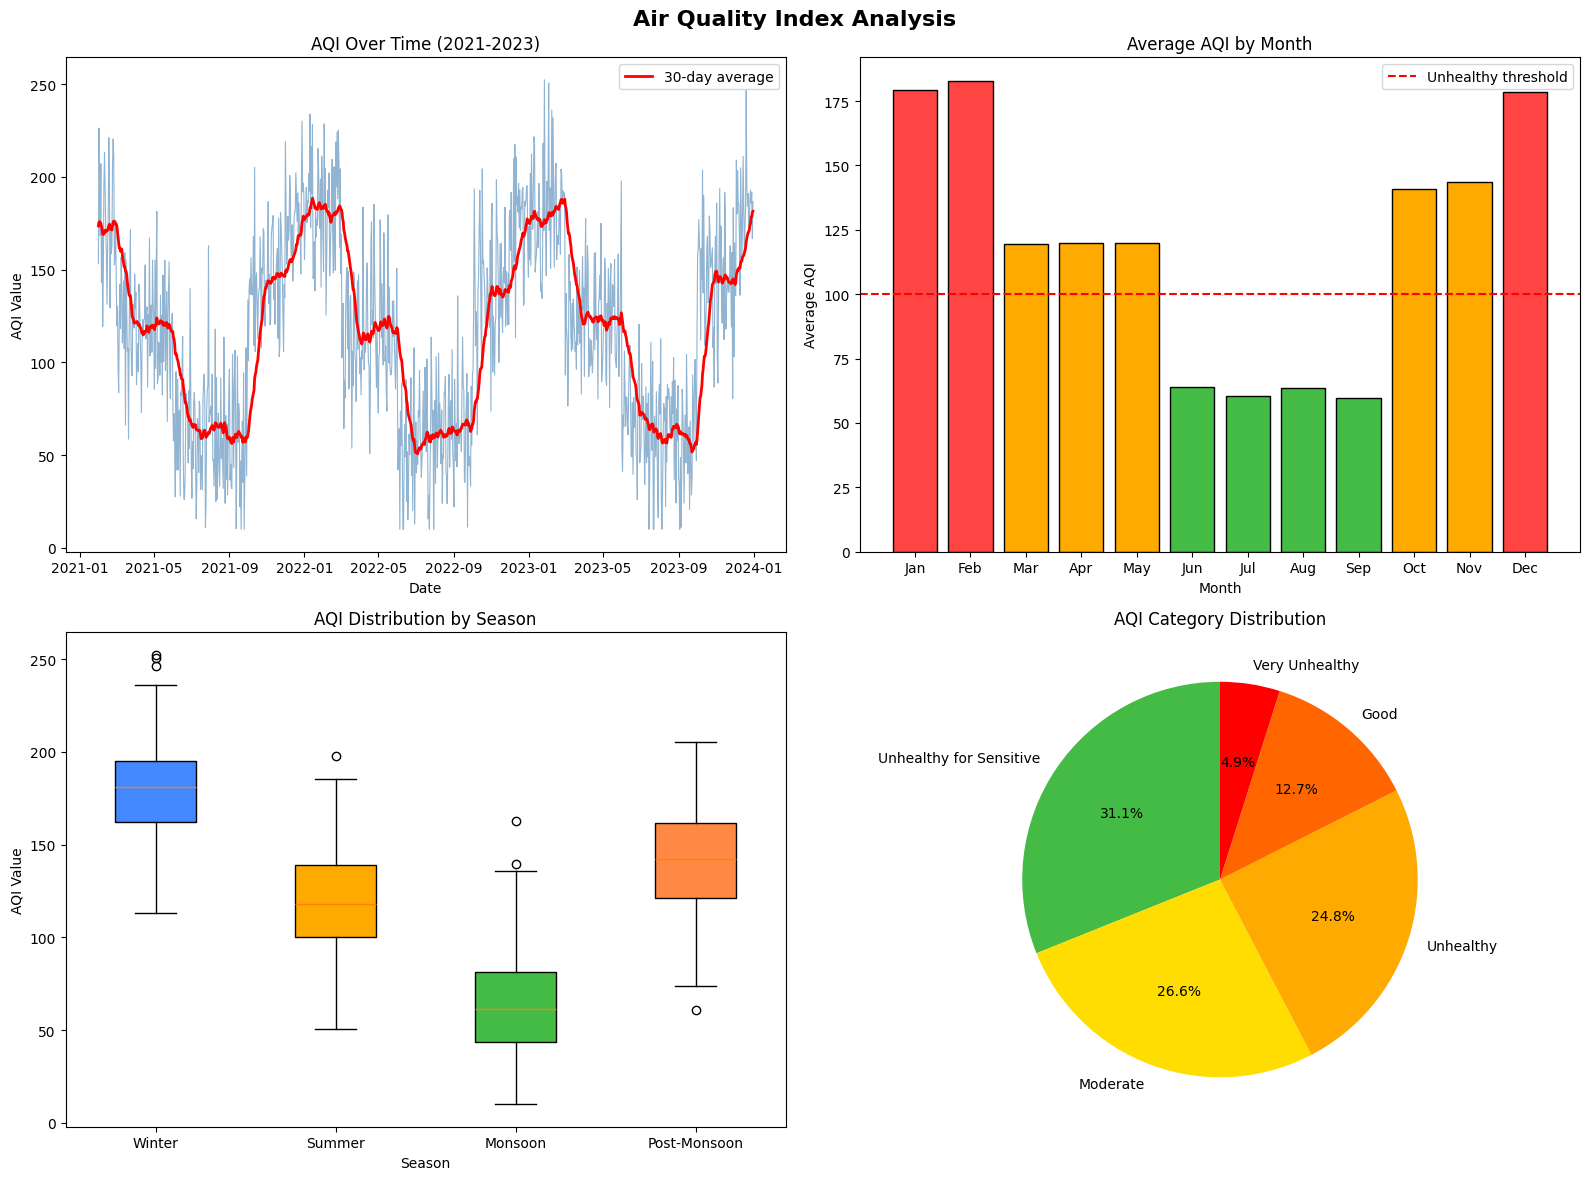

Analysis charts saved!

Training samples: 852 days
Testing samples:  213 days

Model training complete!

MODEL PERFORMANCE
Mean Absolute Error (MAE):  18.81 AQI units
Root Mean Square Error:     23.29 AQI units
R² Score:                   0.8163
Accuracy (R² as %):         81.6%

Interpretation:
On average, predictions are off by 18.8 AQI units


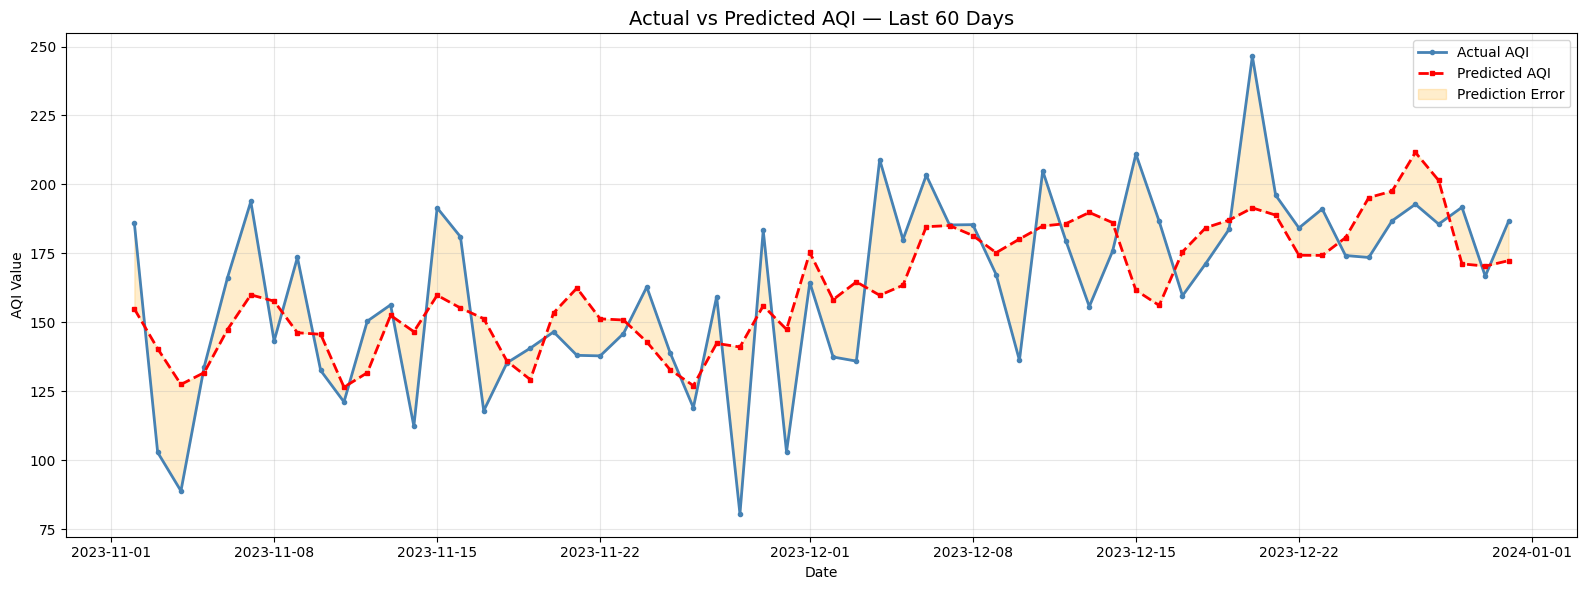

Forecast chart saved!


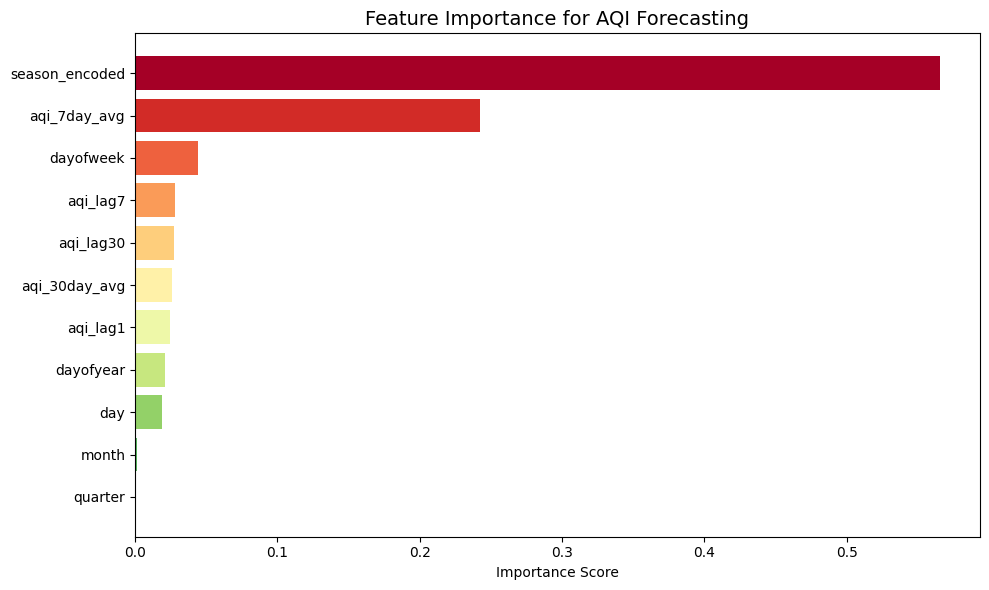


Top 3 most important features:
  season_encoded: 56.5%
  aqi_7day_avg: 24.2%
  dayofweek: 4.4%

7-DAY AQI FORECAST
      Date  Predicted AQI  Category
2024-01-01          194.9 Unhealthy
2024-01-02          194.3 Unhealthy
2024-01-03          191.8 Unhealthy
2024-01-04          191.4 Unhealthy
2024-01-05          179.0 Unhealthy
2024-01-06          177.2 Unhealthy
2024-01-07          177.7 Unhealthy

TASK 2 COMPLETE — FINAL SUMMARY
Dataset:          3 years of AQI data (2021-2023)
Total Records:    1065 days
Model:            Random Forest Regressor
Features Used:    11
Train/Test Split: 80% / 20%
MAE:              18.81 AQI units
R² Score:         0.8163 (81.6%)

Task 2 Successfully Completed! 🌫️


In [ ]:
# ============================================
# TASK 2 - AIR QUALITY INDEX FORECASTING
# Codtech Machine Learning Internship
# Objective: Forecast AQI using historical data
# ============================================

# STEP 1 - IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

# ============================================
# STEP 2 - CREATE REALISTIC AQI DATASET
# ============================================

# Generate realistic AQI dataset with seasonal patterns
# Based on real world air quality patterns in Indian cities
np.random.seed(42)
days = 365 * 3  # 3 years of data

# Date range
dates = pd.date_range(start='2021-01-01', periods=days, freq='D')

# Season based AQI patterns (India)
# Winter = high pollution, Summer = moderate, Monsoon = low
def get_seasonal_aqi(date):
    month = date.month
    if month in [12, 1, 2]:      # Winter - high pollution
        base = 180
    elif month in [3, 4, 5]:     # Summer - moderate
        base = 120
    elif month in [6, 7, 8, 9]:  # Monsoon - low pollution
        base = 60
    else:                         # Post monsoon - rising
        base = 140
    return base

# Generate AQI values with realistic noise
aqi_values = []
for date in dates:
    base_aqi = get_seasonal_aqi(date)
    # Add realistic daily variation
    noise = np.random.normal(0, 25)
    weekly_pattern = 15 * np.sin(2 * np.pi * date.dayofweek / 7)
    aqi = max(10, base_aqi + noise + weekly_pattern)
    aqi_values.append(round(aqi, 1))

# Create main dataframe
df = pd.DataFrame({
    'date': dates,
    'aqi': aqi_values
})

# Add time based features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear
df['quarter'] = df['date'].dt.quarter

# Add season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

df['season'] = df['month'].apply(get_season)

# Add lag features (previous days AQI)
df['aqi_lag1'] = df['aqi'].shift(1)   # yesterday
df['aqi_lag7'] = df['aqi'].shift(7)   # last week
df['aqi_lag30'] = df['aqi'].shift(30) # last month

# Add rolling averages
df['aqi_7day_avg'] = df['aqi'].rolling(window=7).mean()
df['aqi_30day_avg'] = df['aqi'].rolling(window=30).mean()

# Drop rows with NaN from lag features
df = df.dropna()

print("="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Total records: {len(df)} days")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Average AQI: {df['aqi'].mean():.1f}")
print(f"Min AQI: {df['aqi'].min():.1f}")
print(f"Max AQI: {df['aqi'].max():.1f}")
print(f"\nFirst 5 rows:")
print(df[['date', 'aqi', 'season', 'aqi_lag1', 'aqi_7day_avg']].head())

# ============================================
# STEP 3 - AQI CATEGORY ANALYSIS
# ============================================

def aqi_category(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Moderate'
    elif aqi <= 150:
        return 'Unhealthy for Sensitive'
    elif aqi <= 200:
        return 'Unhealthy'
    elif aqi <= 300:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

df['aqi_category'] = df['aqi'].apply(aqi_category)

print("\nAQI Category Distribution:")
print(df['aqi_category'].value_counts())

# ============================================
# STEP 4 - VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Air Quality Index Analysis', fontsize=16, fontweight='bold')

# Chart 1 - AQI over time
axes[0, 0].plot(df['date'], df['aqi'],
                alpha=0.6, color='steelblue', linewidth=0.8)
axes[0, 0].plot(df['date'], df['aqi_30day_avg'],
                color='red', linewidth=2, label='30-day average')
axes[0, 0].set_title('AQI Over Time (2021-2023)')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('AQI Value')
axes[0, 0].legend()

# Chart 2 - Monthly average AQI
monthly_avg = df.groupby('month')['aqi'].mean()
months = ['Jan','Feb','Mar','Apr','May','Jun',
          'Jul','Aug','Sep','Oct','Nov','Dec']
colors_monthly = ['#ff4444' if x > 150 else '#ffaa00'
                  if x > 100 else '#44bb44'
                  for x in monthly_avg]
axes[0, 1].bar(months, monthly_avg, color=colors_monthly, edgecolor='black')
axes[0, 1].set_title('Average AQI by Month')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average AQI')
axes[0, 1].axhline(y=100, color='red', linestyle='--', label='Unhealthy threshold')
axes[0, 1].legend()

# Chart 3 - Seasonal AQI distribution
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
season_colors = ['#4488ff', '#ffaa00', '#44bb44', '#ff8844']
season_data = [df[df['season']==s]['aqi'].values for s in season_order]
bp = axes[1, 0].boxplot(season_data, labels=season_order, patch_artist=True)
for patch, color in zip(bp['boxes'], season_colors):
    patch.set_facecolor(color)
axes[1, 0].set_title('AQI Distribution by Season')
axes[1, 0].set_xlabel('Season')
axes[1, 0].set_ylabel('AQI Value')

# Chart 4 - AQI category distribution
category_counts = df['aqi_category'].value_counts()
cat_colors = ['#44bb44', '#ffdd00', '#ffaa00', '#ff6600', '#ff0000', '#880000']
axes[1, 1].pie(category_counts.values,
               labels=category_counts.index,
               colors=cat_colors[:len(category_counts)],
               autopct='%1.1f%%',
               startangle=90)
axes[1, 1].set_title('AQI Category Distribution')

plt.tight_layout()
plt.savefig('aqi_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Analysis charts saved!")

# ============================================
# STEP 5 - PREPARE DATA FOR ML MODEL
# ============================================

# Encode season (text → numbers for ML)
le = LabelEncoder()
df['season_encoded'] = le.fit_transform(df['season'])

# Features for prediction
features = ['month', 'day', 'dayofweek', 'dayofyear',
            'quarter', 'season_encoded', 'aqi_lag1',
            'aqi_lag7', 'aqi_lag30', 'aqi_7day_avg',
            'aqi_30day_avg']

X = df[features]
y = df['aqi']

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False)

print(f"\nTraining samples: {len(X_train)} days")
print(f"Testing samples:  {len(X_test)} days")

# ============================================
# STEP 6 - TRAIN RANDOM FOREST MODEL
# ============================================

# Random Forest - better than single Decision Tree
# Uses many trees and averages their predictions
model = RandomForestRegressor(
    n_estimators=100,  # 100 decision trees
    max_depth=10,
    random_state=42,
    n_jobs=-1)         # use all CPU cores

model.fit(X_train, y_train)
print("\nModel training complete!")

# Make predictions
y_pred = model.predict(X_test)

# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Mean Absolute Error (MAE):  {mae:.2f} AQI units")
print(f"Root Mean Square Error:     {rmse:.2f} AQI units")
print(f"R² Score:                   {r2:.4f}")
print(f"Accuracy (R² as %):         {r2*100:.1f}%")
print(f"\nInterpretation:")
print(f"On average, predictions are off by {mae:.1f} AQI units")

# ============================================
# STEP 7 - FORECAST VISUALIZATION
# ============================================

plt.figure(figsize=(16, 6))

# Show last 60 days actual vs predicted
last_60 = 60
actual_60 = y_test.values[-last_60:]
predicted_60 = y_pred[-last_60:]
dates_60 = df['date'].values[-last_60:]

plt.plot(dates_60, actual_60,
         color='steelblue', linewidth=2,
         label='Actual AQI', marker='o', markersize=3)
plt.plot(dates_60, predicted_60,
         color='red', linewidth=2,
         label='Predicted AQI', linestyle='--',
         marker='s', markersize=3)
plt.fill_between(dates_60, actual_60, predicted_60,
                 alpha=0.2, color='orange', label='Prediction Error')
plt.title('Actual vs Predicted AQI — Last 60 Days', fontsize=14)
plt.xlabel('Date')
plt.ylabel('AQI Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('aqi_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("Forecast chart saved!")

# ============================================
# STEP 8 - FEATURE IMPORTANCE
# ============================================

feature_imp = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.RdYlGn([i/len(features)
                         for i in range(len(features))])
plt.barh(feature_imp['Feature'],
         feature_imp['Importance'],
         color=colors)
plt.title('Feature Importance for AQI Forecasting', fontsize=14)
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('aqi_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 most important features:")
for idx, row in feature_imp.head(3).iterrows():
    print(f"  {row['Feature']}: {round(row['Importance']*100, 1)}%")

# ============================================
# STEP 9 - FORECAST NEXT 7 DAYS
# ============================================

print("\n" + "="*50)
print("7-DAY AQI FORECAST")
print("="*50)

# Use last known values to predict next 7 days
last_row = df.iloc[-1]
forecasts = []

for i in range(1, 8):
    next_date = last_row['date'] + pd.Timedelta(days=i)
    next_features = [[
        next_date.month,
        next_date.day,
        next_date.dayofweek,
        next_date.dayofyear,
        next_date.quarter,
        le.transform([get_season(next_date.month)])[0],
        last_row['aqi'],           # lag1
        df.iloc[-7]['aqi'],        # lag7
        df.iloc[-30]['aqi'],       # lag30
        df['aqi'].tail(7).mean(),  # 7day avg
        df['aqi'].tail(30).mean()  # 30day avg
    ]]
    pred_aqi = model.predict(next_features)[0]
    category = aqi_category(pred_aqi)
    forecasts.append({
        'Date': next_date.date(),
        'Predicted AQI': round(pred_aqi, 1),
        'Category': category
    })

forecast_df = pd.DataFrame(forecasts)
print(forecast_df.to_string(index=False))

# ============================================
# STEP 10 - FINAL SUMMARY
# ============================================

print("\n" + "="*50)
print("TASK 2 COMPLETE — FINAL SUMMARY")
print("="*50)
print(f"Dataset:          3 years of AQI data (2021-2023)")
print(f"Total Records:    {len(df)} days")
print(f"Model:            Random Forest Regressor")
print(f"Features Used:    {len(features)}")
print(f"Train/Test Split: 80% / 20%")
print(f"MAE:              {mae:.2f} AQI units")
print(f"R² Score:         {r2:.4f} ({r2*100:.1f}%)")
print(f"\nTask 2 Successfully Completed! 🌫️")